## **Building the Miltilayer Perceptron for IRIS dataset**
using the `torch.nn` module to buld the percepron



In [86]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [87]:
iris = load_iris()

X =iris.data
y = iris.target  

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [88]:
# splitting the Dataset
X_train , X_test , y_train , y_test = train_test_split(X, y,
                                                       test_size = 1./3, 
                                                       random_state = 42)
print(f'Shape of the Data' , X_train.shape , y_train.shape , f'TEST SHAPE' , X_test.shape , y_test.shape)

Shape of the Data (100, 4) (100,) TEST SHAPE (50, 4) (50,)


In [89]:
# stanadrize the Data 

# formula for the Z-score is Z --> (Xold - mean)/ stddev

# but can be simply achieved in sklearn
from sklearn.preprocessing import StandardScaler
import torch
import numpy as np
from torch.utils.data import DataLoader , TensorDataset


scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train_norm = torch.from_numpy(y_train)


train_ds = TensorDataset(X_train_norm , y_train_norm)

torch.manual_seed(1)
BATCH_SIZE = 2
train_dl = DataLoader(train_ds ,BATCH_SIZE , shuffle=True)

In [90]:
# creating the NN using the torch.nn
import torch.nn as nn
import torch.nn.functional as F
class Model(nn.Module):
    def __init__(self , input_size , output_size , hidden_size):
        super().__init__()  ## This line of code Enable the nn.module SUPERPOWRS ..!
        
        self.layer1 = nn.Linear(input_size , hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
        
    def forward(self , x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        # x = F.relu(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x) # softmax use to support the 
        return x
    

value = len(np.unique(y_train_norm))

input_size = X_train_norm.shape[1] 
hidden_size = 8
output_size = value

model = Model(input_size= input_size, output_size=output_size, hidden_size=hidden_size)

In [91]:
lr = 0.001
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters() , lr = lr)


In [ ]:
# creating the training loop
n_epochs = 200
loss_hist = [0] * n_epochs
accuracy_hist= [0] * n_epochs

# creatng the training loop

for e in range(n_epochs):
    for x_batch , y_batch in train_dl:
        
        # __forward__pass
        pred = model(x_batch)
        loss = loss_fn(pred , y_batch)
        
        # backward _pass
        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
        
        loss_hist[e] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred , dim=1) == y_batch).sum().item()
        accuracy_hist[e] += is_correct
    
    # torch.argmax use to find the position of the highestvalue in tensor
    
    loss_hist[e] /= len(train_dl.dataset)
    accuracy_hist[e] /= len(train_dl.dataset)
    
    if e % 20 == 0:
        print(f'epoch',e,'loss', loss)
    

epoch 0 loss tensor(1.0830, grad_fn=<NllLossBackward0>)
epoch 20 loss tensor(0.8860, grad_fn=<NllLossBackward0>)
epoch 40 loss tensor(0.8525, grad_fn=<NllLossBackward0>)
epoch 60 loss tensor(0.6156, grad_fn=<NllLossBackward0>)
epoch 80 loss tensor(0.6730, grad_fn=<NllLossBackward0>)
epoch 100 loss tensor(0.5637, grad_fn=<NllLossBackward0>)
epoch 120 loss tensor(0.5858, grad_fn=<NllLossBackward0>)
epoch 140 loss tensor(0.5805, grad_fn=<NllLossBackward0>)
epoch 160 loss tensor(0.5704, grad_fn=<NllLossBackward0>)
epoch 180 loss tensor(0.5596, grad_fn=<NllLossBackward0>)


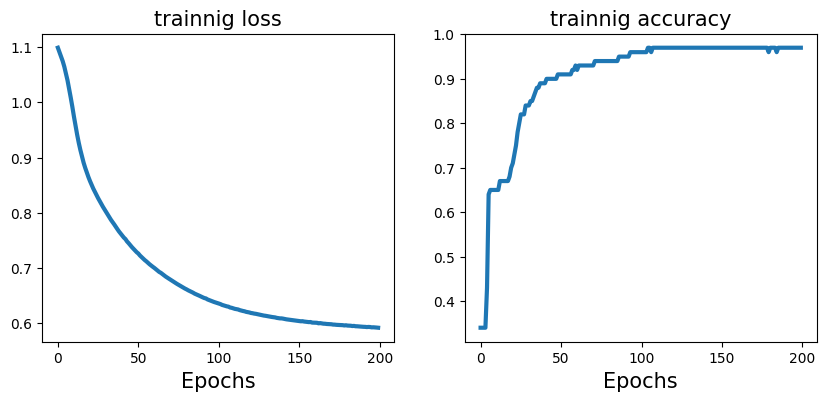

In [93]:
#plotting the learning curve and the Accuracy curve
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,2,1)
ax.plot(loss_hist , lw=3)
ax.set_title('trainnig loss' , size=15)
ax.set_xlabel('Epochs' , size=15)
ax = fig.add_subplot(1,2,2)
ax.plot(accuracy_hist , lw=3)
ax.set_title('trainnig accuracy' , size=15)
ax.set_xlabel('Epochs' , size=15)
plt.show()

### Evaluating the model on the test dataset


In [95]:
X_test_norm = scaler.fit_transform(X_test)
X_test_norm = torch.from_numpy(X_test_norm).float() 
y_test_norm = torch.from_numpy(y_test)

pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test , dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Accuracy : {accuracy:.4f}')

Test Accuracy : 0.9800


### **saving and reloding the same model** 

In [ ]:
path = 'iris_calsifier.pt'
torch.save(model , path)

# calling save model will save both model architechture and learnined parameters 

In [98]:
# reloading the Save model 
model_new = torch.load(path , weights_only=False)

In [99]:
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=3, bias=True)
)

In [100]:
# if only want to save the learninedparameters
path = 'iris_classier_params.pt'
torch.save(model.state_dict(), path)
